# Report 1 — Selective Attention Game: Validation Study
## Pre-Aggregated Pipeline · EDA · Descriptive Statistics · Normality Testing · Non-Parametric Hypothesis Tests

**Design:** 2 × 2 Mixed Factorial  
**N = 37** · Single Target (n = 21) · Multiple Target (n = 16)  
**Factor 1 (between-subjects):** Target Load — Single vs Multiple  
**Factor 2 (within-subjects):** Modality — Lab Task vs Selective Attention Game  
**DVs:** Reaction Time (ms) · Accuracy (%)

---
> **Data source (this version):** Two pre-aggregated CSV files — `participant_rt_by_group.csv`  
> and `participant_accuracy_by_group.csv` — each already at **participant level** (one row  
> per participant). The raw-trial loading, outlier removal, and groupby-averaging steps  
> from the original pipeline are **replaced** by a melt → merge reshape. All downstream  
> statistical logic (Spearman RQ1, Mann-Whitney RQ2, Wilcoxon RQ3, Friedman RQ4) is  
> **identical** to the original notebook.

---
## Section 1 · Introduction

### Selective Attention and the Role of Target Load

Selective attention is the cognitive capacity to concentrate on task-relevant stimuli  
while filtering out competing distractors. Its efficiency is highly sensitive to  
**target load** — the number of targets a participant must identify within a display.  
In a single-target condition, attention can be deployed focally; in a multiple-target  
condition, parallel tracking demands are imposed, increasing cognitive load.

### Study Purpose

This report evaluates a gamified selective-attention task as a potential measurement  
instrument by comparing it against a validated laboratory paradigm (PsychoPy).  
Four research questions assess concurrent validity (RQ1), target-load effects (RQ2),  
modality equivalence (RQ3), and game-level progression effects (RQ4).

### Why Non-Parametric Tests?

Shapiro-Wilk normality tests (Section 5) revealed that at least one condition  
violates the normality assumption. Given small group sizes (n = 16–21), parametric  
tests are also underpowered to detect violations. Non-parametric tests are applied  
consistently across all hypotheses for methodological integrity.

---
## Section 2 · Data Loading & Reshaping

### Input files

| File | Content | Shape |
|---|---|---|
| `participant_rt_by_group.csv` | Mean Reaction Time (ms) per participant | 37 rows × 4 cols |
| `participant_accuracy_by_group.csv` | Mean Accuracy (%) per participant | 37 rows × 4 cols |

### Wide → Long reshape

Both files arrive in **wide format**:

```
ParticipantID | TargetLoad | Game  | Lab
─────────────────────────────────────────
1             | Single     | 3107  | 2331
22            | Multiple   | 1480  | 1330
```

The analysis pipeline expects **long format** with a `Modality` column:

```
ParticipantID | Load     | Modality | RT_ms
────────────────────────────────────────────
1             | Single   | Game     | 3107
1             | Single   | Lab      | 2331
22            | Multiple | Game     | 1480
22            | Multiple | Lab      | 1330
```

This is achieved with `pd.melt()`. The two long frames are then merged on  
`['ParticipantID', 'Load', 'Modality']` to produce the single analysis dataframe `df_part`.

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# 0.  Imports & global plot style
# ════════════════════════════════════════════════════════════════════════════

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, wilcoxon, spearmanr

warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 9,
    'figure.facecolor' : 'white',
})
sns.set_theme(style='whitegrid', font_scale=0.95)

# ── Colour palette (consistent across all figures) ───────────────────────────
PAL = {
    'SL': '#3A7EC6',   # Single Lab
    'SG': '#85C1E9',   # Single Game
    'ML': '#E06B3A',   # Multi Lab
    'MG': '#F0B27A',   # Multi Game
}
COND_ORDER = ['Single\nLab', 'Single\nGame', 'Multi\nLab', 'Multi\nGame']
COND_PAL   = {c: list(PAL.values())[i] for i, c in enumerate(COND_ORDER)}

print('✓ Imports and global style loaded')

✓ Imports and global style loaded


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# 2.1  Load both pre-aggregated CSV files
# ════════════════════════════════════════════════════════════════════════════
# Each file has one row per participant (already participant-level means).
# Columns: ParticipantID | TargetLoad | Game | Lab

df_rt  = pd.read_csv('participant_rt_by_group.csv')
df_acc = pd.read_csv('participant_accuracy_by_group.csv')

print('RT  dataset:', df_rt.shape,  '— columns:', df_rt.columns.tolist())
print('Acc dataset:', df_acc.shape, '— columns:', df_acc.columns.tolist())
print()
print('Target load distribution (RT file):')
print(df_rt['TargetLoad'].value_counts().to_string())
print()
print('=== RT (first 5 rows) ===')
print(df_rt.head().to_string(index=False))
print()
print('=== Accuracy (first 5 rows) ===')
print(df_acc.head().to_string(index=False))

RT  dataset: (37, 4) — columns: ['ParticipantID', 'TargetLoad', 'Game', 'Lab']
Acc dataset: (37, 4) — columns: ['ParticipantID', 'TargetLoad', 'Game', 'Lab']

Target load distribution (RT file):
TargetLoad
Single      21
Multiple    16

=== RT (first 5 rows) ===
 ParticipantID TargetLoad        Game         Lab
             1     Single 3107.333333 2331.349807
             2     Single 3729.125000 1865.424367
             3     Single 2287.062500 1762.399107
             4     Single 2837.562500 1452.931387
             5     Single 3696.789474 1540.257193

=== Accuracy (first 5 rows) ===
 ParticipantID TargetLoad       Game   Lab
             1     Single 100.000000 100.0
             2     Single  93.750000 100.0
             3     Single  93.750000 100.0
             4     Single  93.750000 100.0
             5     Single  78.947368 100.0


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# 2.2  Reshape: wide → long using pd.melt()
# ════════════════════════════════════════════════════════════════════════════
# Before melt (wide):
#   ParticipantID | TargetLoad | Game  | Lab
# After melt (long):
#   ParticipantID | Load       | Modality | RT_ms / Accuracy

# ── RT: wide → long ──────────────────────────────────────────────────────────
rt_long = (df_rt
           .melt(
               id_vars    = ['ParticipantID', 'TargetLoad'],
               value_vars = ['Game', 'Lab'],          # column names become Modality values
               var_name   = 'Modality',
               value_name = 'RT_ms'
           )
           .rename(columns={'TargetLoad': 'Load'})    # standardise column name
          )

# ── Accuracy: wide → long ─────────────────────────────────────────────────────
acc_long = (df_acc
            .melt(
                id_vars    = ['ParticipantID', 'TargetLoad'],
                value_vars = ['Game', 'Lab'],
                var_name   = 'Modality',
                value_name = 'Accuracy'
            )
            .rename(columns={'TargetLoad': 'Load'})
           )

print('RT  long shape:', rt_long.shape,  '  (expected 74 = 37 participants × 2 modalities)')
print('Acc long shape:', acc_long.shape)
print()
print('=== RT long (first 6 rows) ===')
print(rt_long.head(6).to_string(index=False))

RT  long shape: (74, 4)   (expected 74 = 37 participants × 2 modalities)
Acc long shape: (74, 4)

=== RT long (first 6 rows) ===
 ParticipantID   Load Modality       RT_ms
             1 Single     Game 3107.333333
             2 Single     Game 3729.125000
             3 Single     Game 2287.062500
             4 Single     Game 2837.562500
             5 Single     Game 3696.789474
             6 Single     Game 3148.461538


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# 2.3  Merge RT and Accuracy into a single analysis dataframe
# ════════════════════════════════════════════════════════════════════════════
# Merge key: ParticipantID + Load + Modality (uniquely identifies each row)
# No groupby, no averaging, no outlier removal — data is already aggregated.

df_part = pd.merge(
    rt_long,
    acc_long,
    on  = ['ParticipantID', 'Load', 'Modality'],
    how = 'inner'       # keep only rows present in BOTH files (should be all 74)
)

# Add a Condition column matching the original notebook's format (e.g. "Single\nLab")
df_part['Condition'] = (
    df_part['Load'].str.replace('Multiple', 'Multi', regex=False)
    + '\n'
    + df_part['Modality']
)

# Sort for readability
df_part = df_part.sort_values(['Load', 'Modality', 'ParticipantID']).reset_index(drop=True)

print(f'df_part shape: {df_part.shape}  (expected 74 = 37 participants × 2 modalities)')
print()
print('Row counts per condition:')
print(df_part.groupby(['Load', 'Modality'])['ParticipantID'].count().to_string())
print()
print('=== df_part (first 8 rows) ===')
print(df_part[['ParticipantID','Load','Modality','Condition','RT_ms','Accuracy']]
      .head(8).to_string(index=False))
print()

# Sanity check: no missing values should exist after a clean melt + merge
missing = df_part[['RT_ms','Accuracy']].isnull().sum()
print('Missing values:', missing.to_dict(),
      '← should be 0 if CSVs are complete')

df_part shape: (74, 6)  (expected 74 = 37 participants × 2 modalities)

Row counts per condition:
Load      Modality
Multiple  Game        16
          Lab         16
Single    Game        21
          Lab         21

=== df_part (first 8 rows) ===
 ParticipantID     Load Modality   Condition       RT_ms   Accuracy
            22 Multiple     Game Multi\nGame 1480.750000  98.616000
            23 Multiple     Game Multi\nGame 1969.416667  98.214167
            24 Multiple     Game Multi\nGame 3120.416667  88.214167
            25 Multiple     Game Multi\nGame 1176.700000 100.000000
            26 Multiple     Game Multi\nGame 2160.727273  98.051818
            27 Multiple     Game Multi\nGame 2547.727273  98.701818
            28 Multiple     Game Multi\nGame 1685.250000  98.809167
            29 Multiple     Game Multi\nGame 1746.090909  98.051818

Missing values: {'RT_ms': 0, 'Accuracy': 0} ← should be 0 if CSVs are complete


---
## Section 3 · Exploratory Data Analysis & Visualisation

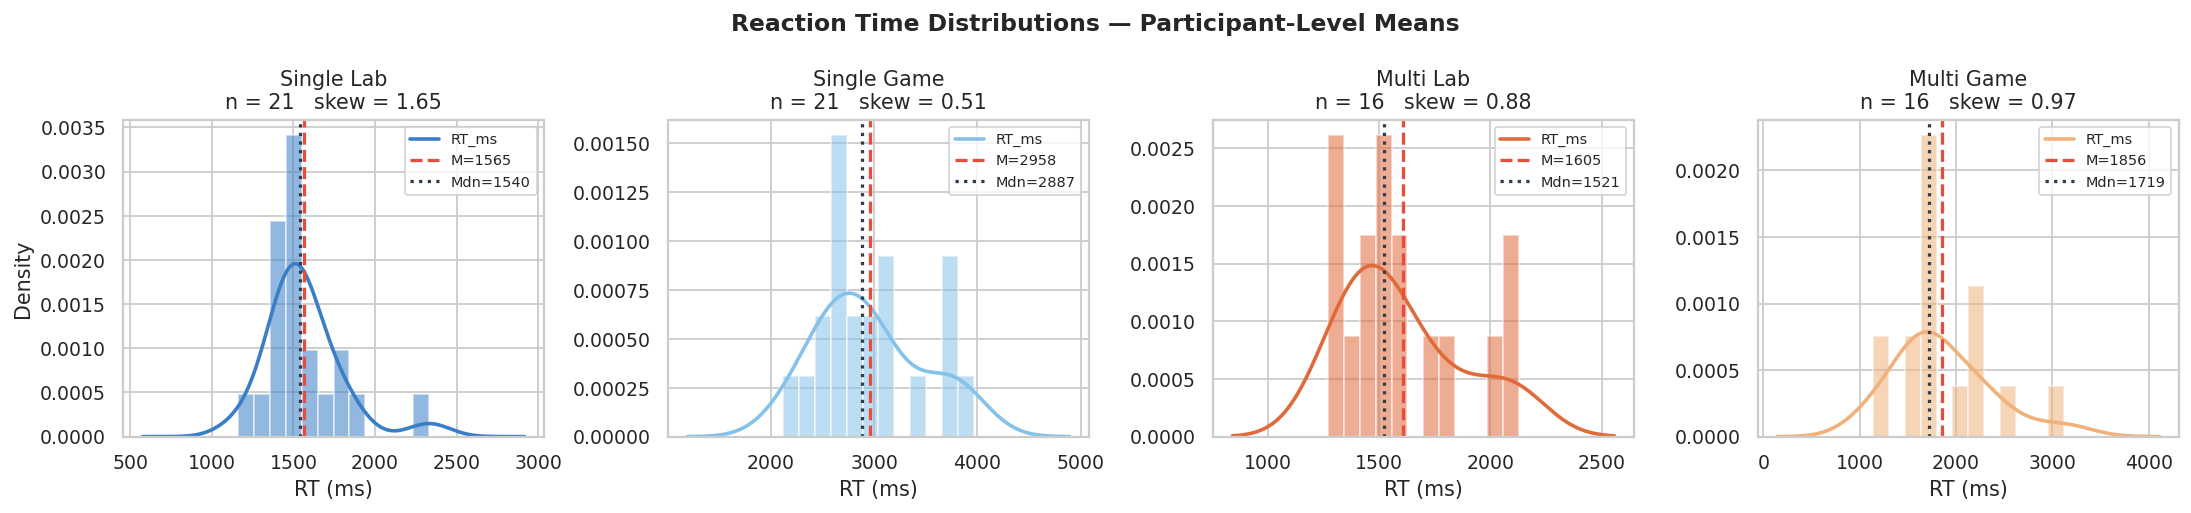

✓ Figure 1 saved


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# 3.1  RT distributions per condition — participant-level data
# ════════════════════════════════════════════════════════════════════════════
# Each point = one participant's mean RT.  With n = 16–21 per group these are
# histograms of the same values that enter the hypothesis tests.

fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharey=False)
fig.suptitle('Reaction Time Distributions — Participant-Level Means',
             fontsize=13, fontweight='bold')

for col, cond in enumerate(COND_ORDER):
    ax    = axes[col]
    color = list(PAL.values())[col]
    dat   = df_part[df_part['Condition'] == cond]['RT_ms'].dropna()

    # Histogram + KDE
    ax.hist(dat, bins=12, color=color, alpha=0.55, density=True,
            edgecolor='white', lw=0.5)
    if len(dat) >= 4:
        dat.plot.kde(ax=ax, color=color, lw=2)

    ax.axvline(dat.mean(),   color='#E74C3C', lw=1.8, ls='--',
               label=f'M={dat.mean():.0f}')
    ax.axvline(dat.median(), color='#2C3E50', lw=1.8, ls=':',
               label=f'Mdn={dat.median():.0f}')

    ax.set_title(f'{cond.replace(chr(10), " ")}\n'
                 f'n = {len(dat)}   skew = {dat.skew():.2f}')
    ax.set_xlabel('RT (ms)')
    ax.set_ylabel('Density' if col == 0 else '')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig01_rt_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 1 saved')

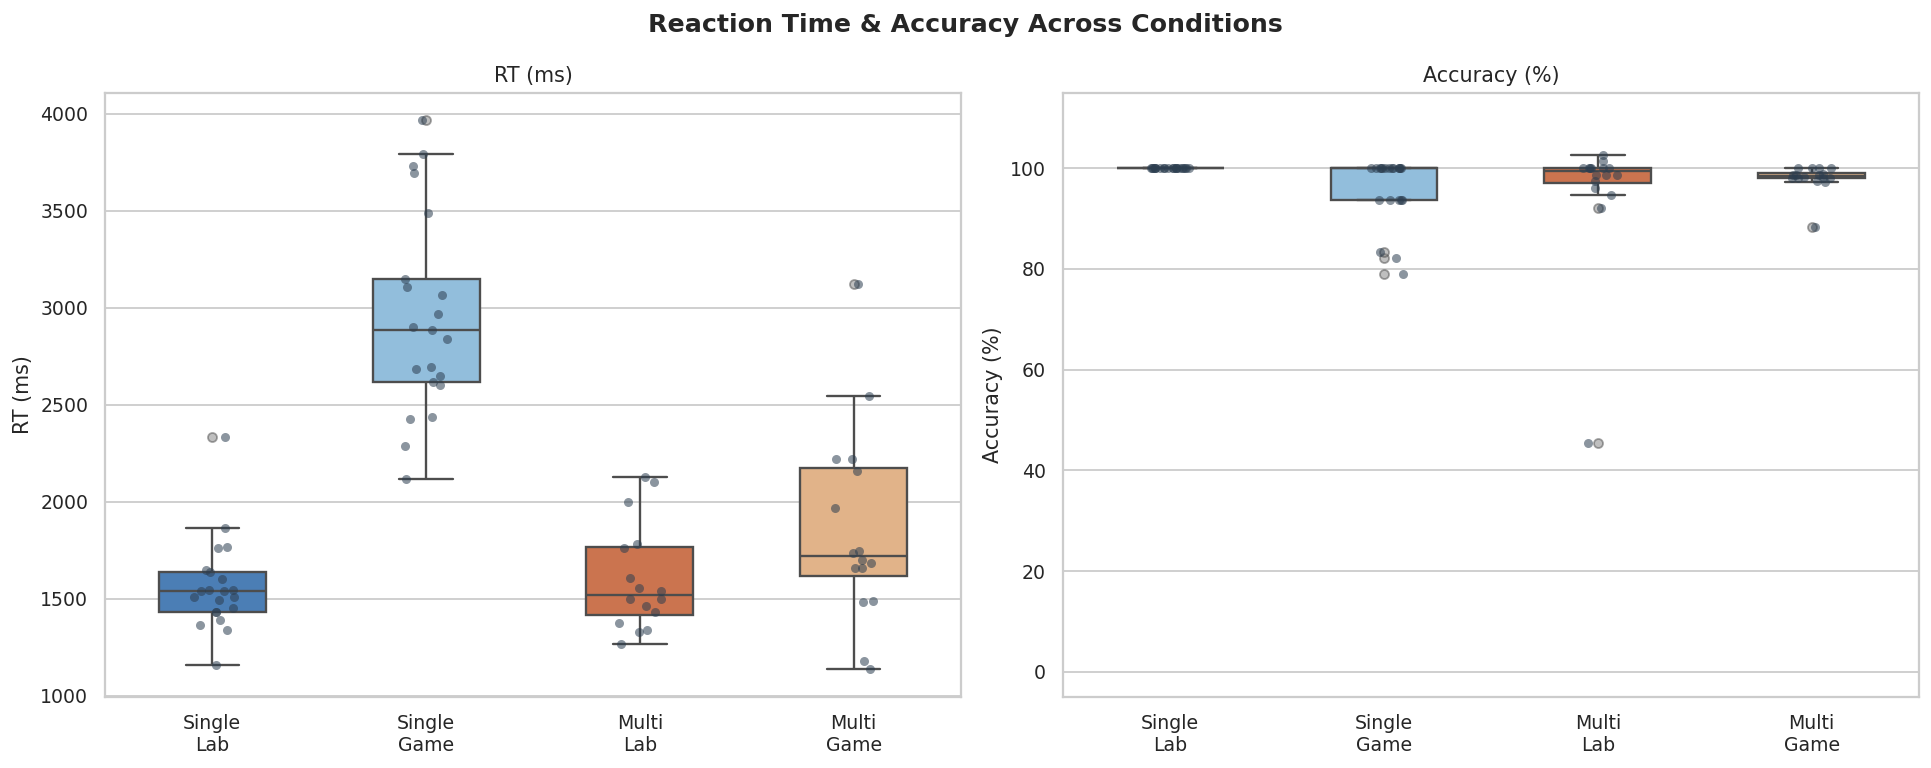

✓ Figure 2 saved


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# 3.2  Boxplots — RT and Accuracy across 4 conditions
# ════════════════════════════════════════════════════════════════════════════
# Strip plot overlaid so every participant's score is visible.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Reaction Time & Accuracy Across Conditions',
             fontsize=14, fontweight='bold')

for ax, dv, ylabel, ylim in [
        (axes[0], 'RT_ms',    'RT (ms)',           None),
        (axes[1], 'Accuracy', 'Accuracy (%)',       (-5, 115))]:

    sns.boxplot(data=df_part, x='Condition', y=dv,
                order=COND_ORDER, palette=COND_PAL,
                width=0.50, linewidth=1.3,
                flierprops=dict(marker='o', ms=5, alpha=0.5,
                                markerfacecolor='grey'),
                ax=ax)
    sns.stripplot(data=df_part, x='Condition', y=dv,
                  order=COND_ORDER, color='#2C3E50',
                  alpha=0.55, size=5, jitter=True, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    if ylim:
        ax.set_ylim(ylim)

plt.tight_layout()
plt.savefig('fig02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 2 saved')

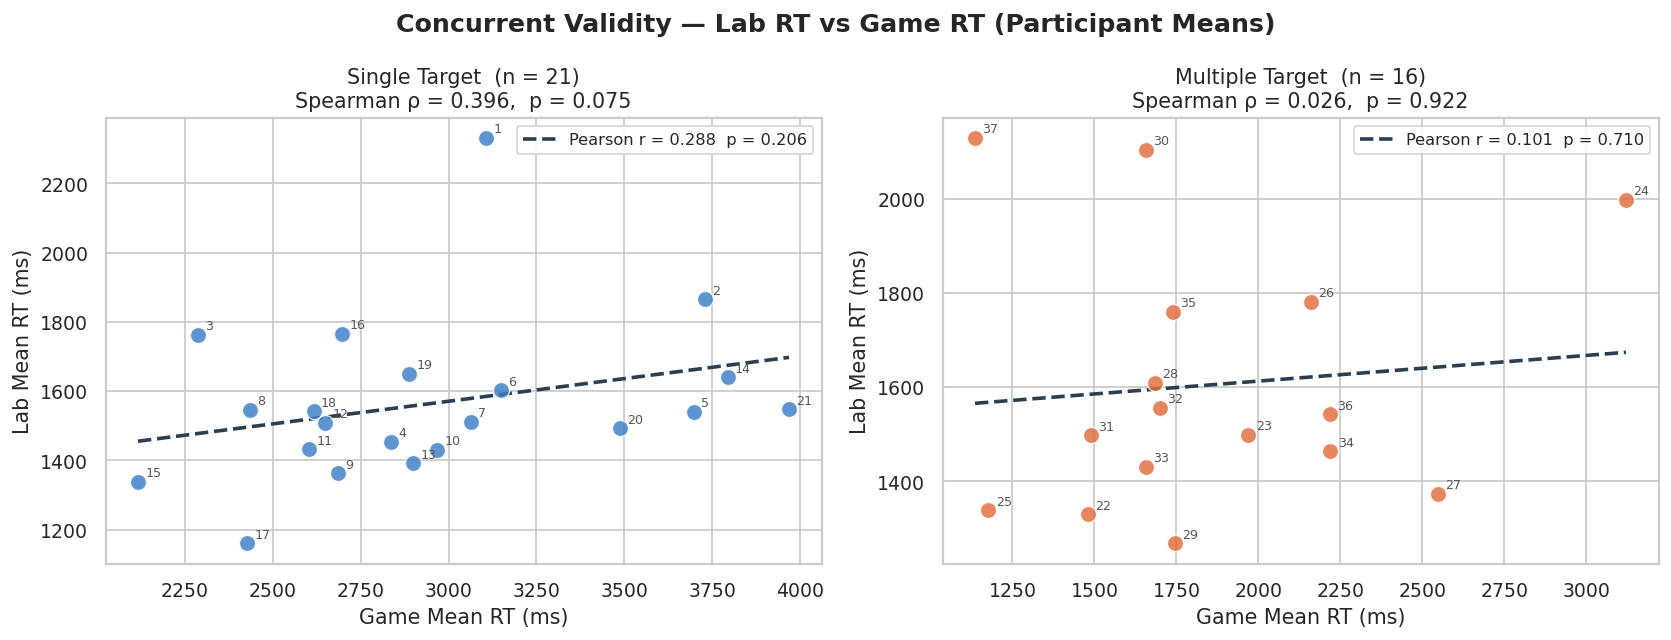

✓ Figure 3 saved


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# 3.3  Scatter plots — Lab RT vs Game RT  (Concurrent Validity, RQ1 preview)
# ════════════════════════════════════════════════════════════════════════════
# Because df_part is already at participant level, paired Lab/Game values are
# simply two rows per participant — pivot on Modality to align them.

scatter_df = (df_part[['ParticipantID', 'Load', 'Modality', 'RT_ms']]
              .pivot_table(index=['ParticipantID', 'Load'],
                           columns='Modality',
                           values='RT_ms')
              .dropna()                    # keep only participants with BOTH modalities
              .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Concurrent Validity — Lab RT vs Game RT (Participant Means)',
             fontsize=14, fontweight='bold')

for ax, load, color in [(axes[0], 'Single', '#3A7EC6'),
                        (axes[1], 'Multiple', '#E06B3A')]:
    sub = scatter_df[scatter_df['Load'] == load]

    ax.scatter(sub['Game'], sub['Lab'],
               color=color, s=80, alpha=0.82,
               edgecolors='white', linewidths=0.8, zorder=3)

    # Annotate each point with its ParticipantID
    for _, row in sub.iterrows():
        ax.annotate(str(int(row['ParticipantID'])),
                    (row['Game'], row['Lab']),
                    fontsize=7, xytext=(4, 3),
                    textcoords='offset points', color='#555555')

    # OLS regression line + Spearman ρ in title
    if len(sub) >= 3:
        m, b, r_pear, p_pear, _ = stats.linregress(sub['Game'], sub['Lab'])
        xs = np.linspace(sub['Game'].min(), sub['Game'].max(), 100)
        ax.plot(xs, m * xs + b, color='#2C3E50', lw=2, ls='--',
                label=f'Pearson r = {r_pear:.3f}  p = {p_pear:.3f}')

        rho, p_spear = spearmanr(sub['Lab'], sub['Game'])
        ax.set_title(f'{load} Target  (n = {len(sub)})\n'
                     f'Spearman ρ = {rho:.3f},  p = {p_spear:.3f}')
        ax.legend(fontsize=9)

    ax.set_xlabel('Game Mean RT (ms)')
    ax.set_ylabel('Lab Mean RT (ms)')

plt.tight_layout()
plt.savefig('fig03_scatter_validity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 3 saved')

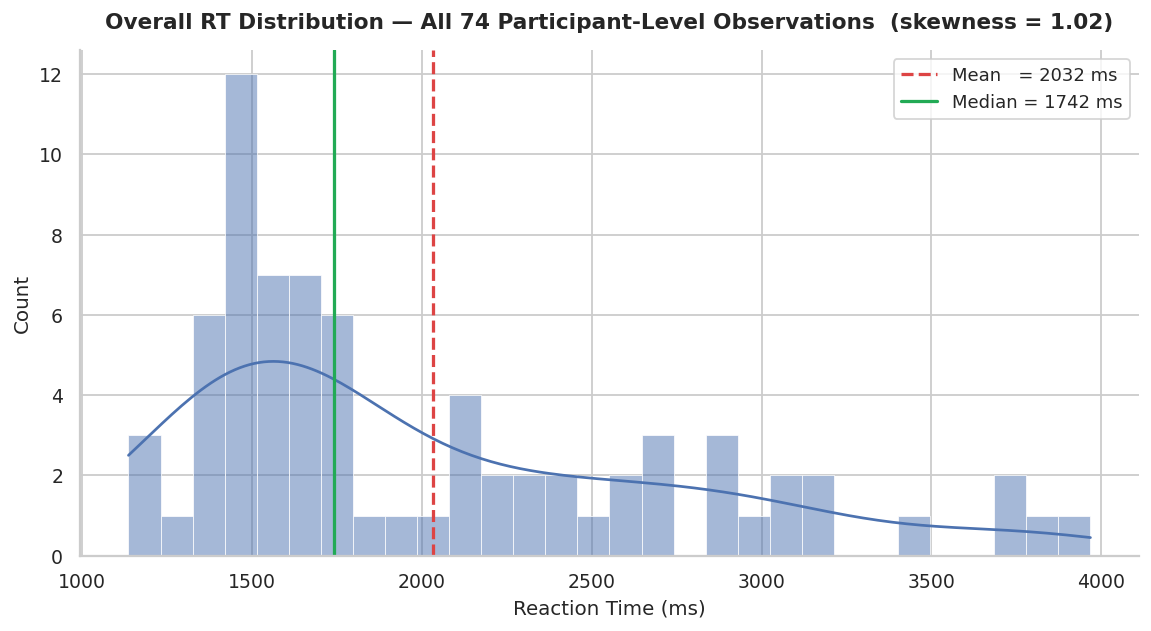

  Mean     : 2032.0 ms
  Median   : 1742.1 ms
  Std Dev  : 716.7 ms
  Skewness : 1.025  (right-skewed → supports use of non-parametric tests)


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# 3.4  Overall RT histogram with KDE — supports use of non-parametric tests
# ════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 5))
skew_val = df_part['RT_ms'].skew()

sns.histplot(df_part['RT_ms'], bins=30, kde=True,
             color='#4C72B0', edgecolor='white', linewidth=0.4, ax=ax)
ax.axvline(df_part['RT_ms'].mean(),   color='#DD4444', lw=1.8, ls='--',
           label=f"Mean   = {df_part['RT_ms'].mean():.0f} ms")
ax.axvline(df_part['RT_ms'].median(), color='#22AA55', lw=1.8, ls='-',
           label=f"Median = {df_part['RT_ms'].median():.0f} ms")

ax.set_title(f'Overall RT Distribution — All 74 Participant-Level Observations'
             f'  (skewness = {skew_val:.2f})',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Reaction Time (ms)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('fig04_rt_overall.png', dpi=150, bbox_inches='tight')
plt.show()

direction = ('right-skewed → supports use of non-parametric tests'
             if skew_val > 0.5 else 'approximately symmetric')
print(f'  Mean     : {df_part["RT_ms"].mean():.1f} ms')
print(f'  Median   : {df_part["RT_ms"].median():.1f} ms')
print(f'  Std Dev  : {df_part["RT_ms"].std():.1f} ms')
print(f'  Skewness : {skew_val:.3f}  ({direction})')

---
## Section 4 · Descriptive Statistics

Mean (M), Standard Deviation (SD), and Median are reported at the **participant level**  
(one observation per person per condition) — which is exactly the structure of `df_part`.

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# 4.1  Descriptive statistics table
# ════════════════════════════════════════════════════════════════════════════

desc_rows = []
for cond in COND_ORDER:
    sub = df_part[df_part['Condition'] == cond]
    for dv, label in [('RT_ms', 'RT (ms)'), ('Accuracy', 'Accuracy (%)')]:
        vals = sub[dv].dropna()
        n    = len(vals)
        se   = vals.std() / np.sqrt(n) if n > 1 else np.nan
        desc_rows.append({
            'Condition' : cond.replace('\n', ' '),
            'DV'        : label,
            'N'         : n,
            'M'         : round(vals.mean(), 2),
            'SD'        : round(vals.std(),  2),
            'SE'        : round(se,          2),
            'Median'    : round(vals.median(),2),
            'Min'       : round(vals.min(),  2),
            'Max'       : round(vals.max(),  2),
        })

desc_df = pd.DataFrame(desc_rows)
print(desc_df.to_string(index=False))

  Condition           DV  N       M     SD     SE  Median     Min     Max
 Single Lab      RT (ms) 21 1565.41 236.54  51.62 1540.26 1160.46 2331.35
 Single Lab Accuracy (%) 21  100.00   0.00   0.00  100.00  100.00  100.00
Single Game      RT (ms) 21 2957.55 520.82 113.65 2887.47 2116.81 3968.20
Single Game Accuracy (%) 21   95.86   6.63   1.45  100.00   78.95  100.00
  Multi Lab      RT (ms) 16 1605.04 273.65  68.41 1520.59 1268.69 2128.54
  Multi Lab Accuracy (%) 16   95.33  13.59   3.40   99.33   45.33  102.67
 Multi Game      RT (ms) 16 1856.46 507.28 126.82 1719.13 1135.92 3120.42
 Multi Game Accuracy (%) 16   98.02   2.76   0.69   98.42   88.21  100.00


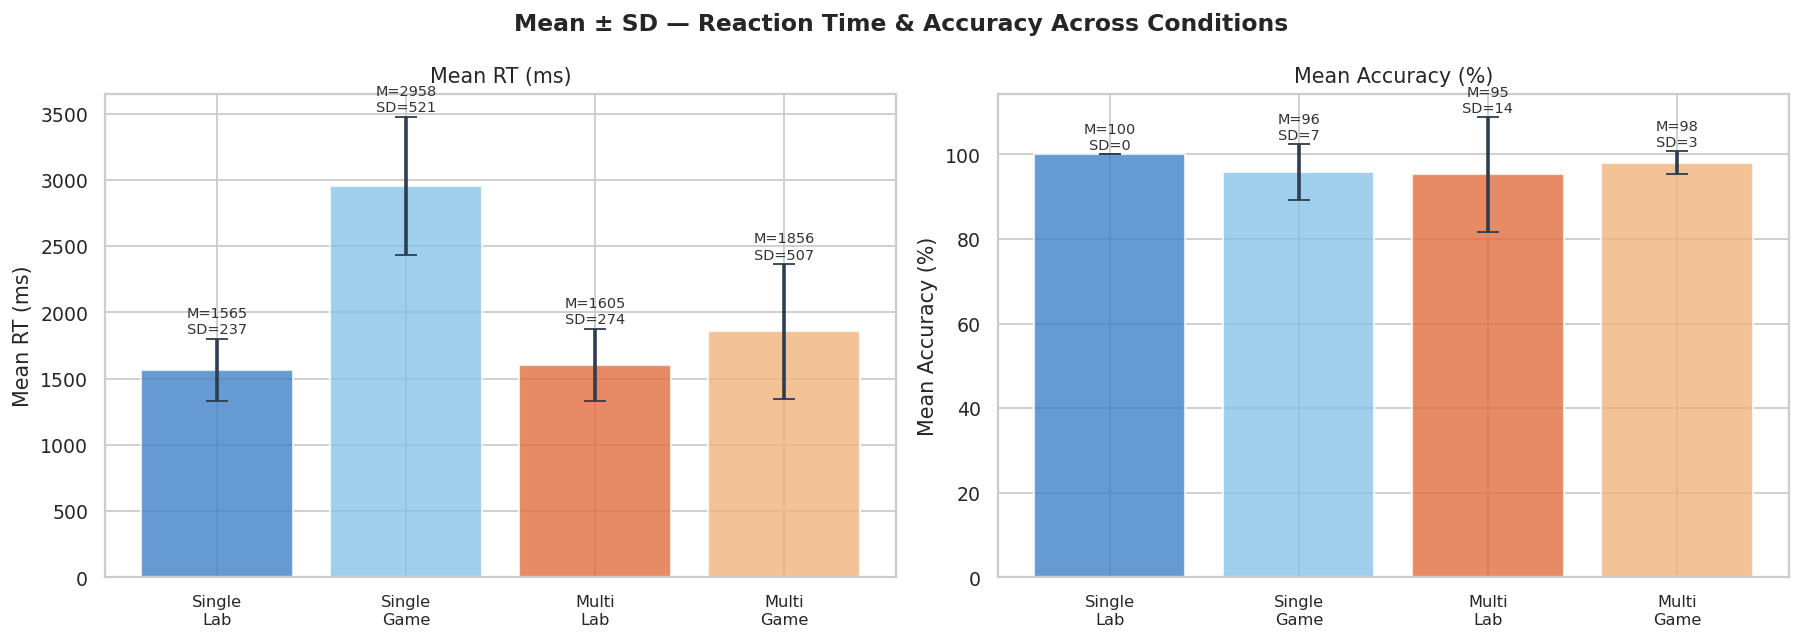

✓ Figure 5 saved


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# 4.2  Mean ± SD bar chart
# ════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mean ± SD — Reaction Time & Accuracy Across Conditions',
             fontsize=13, fontweight='bold')

for ax, dv, ylabel in [
        (axes[0], 'RT_ms',    'Mean RT (ms)'),
        (axes[1], 'Accuracy', 'Mean Accuracy (%)')]:

    cond_stats = (df_part.groupby('Condition')[dv]
                  .agg(['mean', 'std', 'count'])
                  .reindex(COND_ORDER))
    cond_stats['se'] = cond_stats['std'] / np.sqrt(cond_stats['count'])

    ax.bar(range(4), cond_stats['mean'],
           color=[COND_PAL[c] for c in COND_ORDER],
           alpha=0.78, edgecolor='white', linewidth=1.2)
    ax.errorbar(range(4), cond_stats['mean'],
                yerr=cond_stats['std'], fmt='none',
                color='#2C3E50', capsize=6, lw=2)
    ax.set_xticks(range(4))
    ax.set_xticklabels(COND_ORDER, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

    for i, (_, row) in enumerate(cond_stats.iterrows()):
        offset = cond_stats['std'].max() * 0.08
        ax.text(i, row['mean'] + row['std'] + offset,
                f"M={row['mean']:.0f}\nSD={row['std']:.0f}",
                ha='center', fontsize=8, color='#333333')

plt.tight_layout()
plt.savefig('fig05_means_sd.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 5 saved')

---
## Section 5 · Normality Testing — Shapiro-Wilk

The Shapiro-Wilk test is the most powerful normality test for small samples (n < 50).

- **H₀:** The data follow a normal distribution.  
- **H₁:** The data do not follow a normal distribution.  
- **Decision rule:** Reject H₀ if p < .05.

### Why this matters

Parametric tests (t-test, ANOVA) assume normality. If any condition departs from  
normality — especially with small n — non-parametric tests are applied consistently  
across all hypotheses to maintain methodological integrity.

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# 5.1  Shapiro-Wilk test on participant-level means
# ════════════════════════════════════════════════════════════════════════════

sw_rows = []
for cond in COND_ORDER:
    sub = df_part[df_part['Condition'] == cond]
    for dv, dv_label in [('RT_ms', 'RT (ms)'), ('Accuracy', 'Accuracy (%)')]:
        vals = sub[dv].dropna()
        n    = len(vals)
        if n < 3:
            sw_rows.append({'Condition': cond.replace('\n', ' '),
                            'DV': dv_label, 'N': n,
                            'W': np.nan, 'p': np.nan, 'Verdict': '< 3 obs'})
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')   # suppress constant-data warnings
            w_stat, p_val = shapiro(vals)
        verdict = '✗ NON-NORMAL' if p_val < 0.05 else '✓ Normal'
        sw_rows.append({'Condition': cond.replace('\n', ' '),
                        'DV': dv_label, 'N': n,
                        'W': round(w_stat, 4), 'p': round(p_val, 4),
                        'Verdict': verdict})

sw_df = pd.DataFrame(sw_rows)
print(sw_df.to_string(index=False))
print()
print('─' * 60)
any_nonnormal = (sw_df['p'] < 0.05).any()
print(f'Any condition violates normality (p < .05): {any_nonnormal}')
print()
print('DECISION:')
if any_nonnormal:
    print('  At least one condition fails Shapiro-Wilk (p < .05).')
    print('  → Non-parametric tests applied to ALL research questions')
    print('    for methodological consistency.')
else:
    print('  All conditions pass normality — but n is small, limiting power.')
    print('  → Non-parametric tests applied as a conservative, robust choice.')

  Condition           DV  N      W      p      Verdict
 Single Lab      RT (ms) 21 0.8690 0.0092 ✗ NON-NORMAL
 Single Lab Accuracy (%) 21 1.0000 1.0000     ✓ Normal
Single Game      RT (ms) 21 0.9461 0.2869     ✓ Normal
Single Game Accuracy (%) 21 0.6696 0.0000 ✗ NON-NORMAL
  Multi Lab      RT (ms) 16 0.8910 0.0579     ✓ Normal
  Multi Lab Accuracy (%) 16 0.4373 0.0000 ✗ NON-NORMAL
 Multi Game      RT (ms) 16 0.9262 0.2124     ✓ Normal
 Multi Game Accuracy (%) 16 0.5711 0.0000 ✗ NON-NORMAL

────────────────────────────────────────────────────────────
Any condition violates normality (p < .05): True

DECISION:
  At least one condition fails Shapiro-Wilk (p < .05).
  → Non-parametric tests applied to ALL research questions
    for methodological consistency.


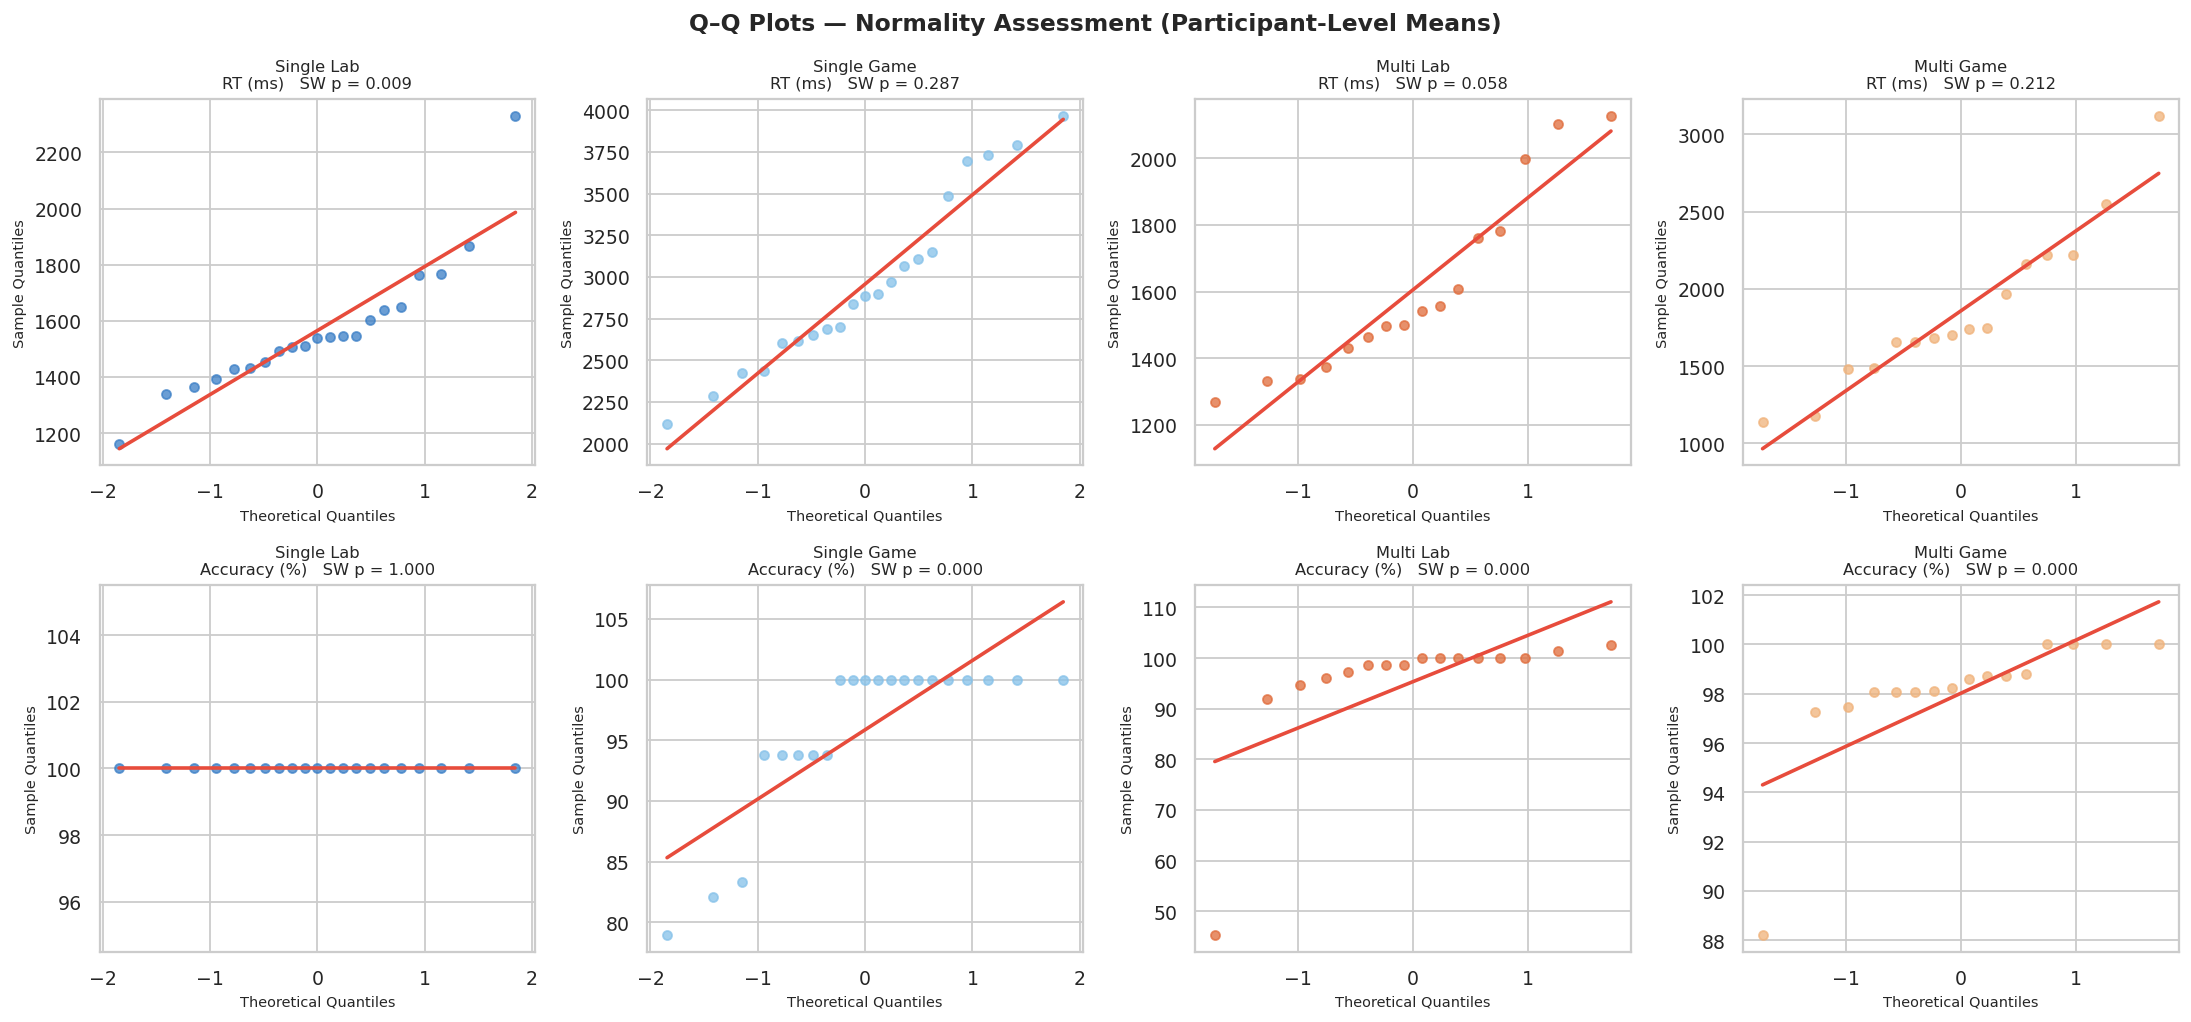

✓ Figure 6 saved


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# 5.2  Q–Q plots — visual normality assessment
# ════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
fig.suptitle('Q–Q Plots — Normality Assessment (Participant-Level Means)',
             fontsize=13, fontweight='bold')

dvs = [('RT_ms', 'RT (ms)'), ('Accuracy', 'Accuracy (%)')]

for row_idx, (dv, dv_label) in enumerate(dvs):
    for col_idx, cond in enumerate(COND_ORDER):
        ax    = axes[row_idx, col_idx]
        vals  = df_part[df_part['Condition'] == cond][dv].dropna().values
        color = list(PAL.values())[col_idx]

        if len(vals) < 3:
            ax.text(0.5, 0.5, 'n < 3', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12)
        else:
            (osm, osr), (slope, intercept, _) = stats.probplot(vals, dist='norm')
            ax.plot(osm, osr, 'o', color=color, alpha=0.75, ms=5, zorder=2)
            ax.plot(osm, slope * np.array(osm) + intercept,
                    color='#E74C3C', lw=2, zorder=3)
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                w_stat, p_val = shapiro(vals)
            ax.set_title(f'{cond.replace(chr(10), " ")}\n'
                         f'{dv_label}   SW p = {p_val:.3f}',
                         fontsize=9)
        ax.set_xlabel('Theoretical Quantiles', fontsize=8)
        ax.set_ylabel('Sample Quantiles', fontsize=8)

plt.tight_layout()
plt.savefig('fig06_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 6 saved')

---
## Research Questions

- **RQ1 — Concurrent Validity:** Is there a significant positive correlation between  
  Game RT and Lab RT? Tests whether the game measures the same construct as the lab task.

- **RQ2 — Target Load Effect:** Do Single vs Multiple target groups differ significantly  
  in RT? Tests the between-subjects manipulation.

- **RQ3 — Modality Effect:** Do Game and Lab RTs differ within participants?  
  Tests interface equivalence (within-subjects).

- **RQ4 — Game Level Effect:** Does RT change systematically across game difficulty  
  levels? Not applicable here — aggregated data has no level information.

---
## Section 6 · Non-Parametric Hypothesis Tests

### Hypotheses

**RQ1 — Concurrent Validity (Spearman's ρ)**  
- **H₀:** There is no monotonic correlation between Game RT and Lab RT (ρ = 0).  
- **H₁:** There is a positive monotonic correlation (ρ > 0).  
- *Test:* Spearman's rank-order correlation, separately for Single and Multiple groups.

**RQ2 — Target Load Effect (Mann-Whitney U)**  
- **H₀:** There is no difference in RT between Single and Multiple target groups.  
- **H₁:** RT differs between the two target-load groups (two-tailed).  
- *Test:* Mann-Whitney U on participant-level RT, separately per modality.

**RQ3 — Modality Effect (Wilcoxon Signed-Rank)**  
- **H₀:** There is no difference in RT between Game and Lab modalities.  
- **H₁:** RT differs between Game and Lab (two-tailed).  
- *Test:* Wilcoxon signed-rank on paired Lab/Game RT, separately per load group.  
- *Pairing:* via `pivot_table(index='ParticipantID', columns='Modality')`.

**RQ4 — Game Level Effect (Friedman)**  
- Skipped: the aggregated CSV files do not contain per-level data.

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# 6.0  Helper functions — effect sizes
# ════════════════════════════════════════════════════════════════════════════

def rank_biserial_U(u_stat, n1, n2):
    """Rank-biserial r for Mann-Whitney U: r = 1 − 2U / (n1 × n2)."""
    return 1 - (2 * u_stat) / (n1 * n2)

def rank_biserial_W(w_stat, n):
    """Rank-biserial r for Wilcoxon W: r ≈ W / (n(n+1)/2)."""
    return w_stat / (n * (n + 1) / 2)

sep = '═' * 65

print('✓ Helper functions loaded')

✓ Helper functions loaded


In [14]:
# ════════════════════════════════════════════════════════════════════════════
# 6.1  RQ1 — Spearman's ρ: Lab RT vs Game RT  (Concurrent Validity)
# ════════════════════════════════════════════════════════════════════════════
# df_part is already at participant level — no further averaging needed.
# Pivot on Modality to align each participant's Lab and Game scores as columns,
# then correlate.  dropna() keeps only participants with BOTH modalities.

print(sep)
print("RQ1  CONCURRENT VALIDITY — Spearman's ρ")
print(sep)

# Build paired Lab/Game RT table
paired_rt = (df_part[['ParticipantID', 'Load', 'Modality', 'RT_ms']]
             .pivot_table(index=['ParticipantID', 'Load'],
                          columns='Modality',
                          values='RT_ms')
             .dropna()
             .rename(columns={'Lab': 'Lab_RT', 'Game': 'Game_RT'})
             .reset_index())

print(f"\nPaired participants (Lab ∩ Game):")
print(f"  Single  : n = {len(paired_rt[paired_rt['Load']=='Single'])}")
print(f"  Multiple: n = {len(paired_rt[paired_rt['Load']=='Multiple'])}")
print(f"  Combined: n = {len(paired_rt)}")
print()

for load in ['Single', 'Multiple', 'Combined']:
    sub = paired_rt if load == 'Combined' else paired_rt[paired_rt['Load'] == load]
    n   = len(sub)
    if n < 3:
        print(f"  {load}: n = {n} — insufficient for correlation"); continue

    rho, p = spearmanr(sub['Lab_RT'], sub['Game_RT'])

    # 95% CI via Fisher z-transformation
    z     = np.arctanh(rho)
    se_z  = 1 / np.sqrt(n - 3)
    ci_lo = np.tanh(z - 1.96 * se_z)
    ci_hi = np.tanh(z + 1.96 * se_z)
    sig   = 'REJECT H₀' if p < 0.05 else 'FAIL TO REJECT H₀'

    print(f"  {load} (n = {n}):")
    print(f"    Spearman ρ = {rho:.3f},  p = {p:.4f}")
    print(f"    95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]")
    print(f"    → {sig}")
    print()

═════════════════════════════════════════════════════════════════
RQ1  CONCURRENT VALIDITY — Spearman's ρ
═════════════════════════════════════════════════════════════════

Paired participants (Lab ∩ Game):
  Single  : n = 21
  Multiple: n = 16
  Combined: n = 37

  Single (n = 21):
    Spearman ρ = 0.396,  p = 0.0755
    95% CI: [-0.043, 0.707]
    → FAIL TO REJECT H₀

  Multiple (n = 16):
    Spearman ρ = 0.026,  p = 0.9225
    95% CI: [-0.475, 0.515]
    → FAIL TO REJECT H₀

  Combined (n = 37):
    Spearman ρ = 0.182,  p = 0.2814
    95% CI: [-0.151, 0.478]
    → FAIL TO REJECT H₀



In [15]:
# ════════════════════════════════════════════════════════════════════════════
# 6.2  RQ2 — Mann-Whitney U: Single vs Multiple Target Load
# ════════════════════════════════════════════════════════════════════════════
# Independent-groups test: Single and Multiple are different participants
# (between-subjects factor).  Tested separately within each modality.

print(sep)
print('RQ2  TARGET LOAD EFFECT — Mann-Whitney U  (two-tailed)')
print(sep)

for modality in ['Lab', 'Game']:
    print(f"\n  Modality = {modality}:")

    single_rt = (df_part[(df_part['Load'] == 'Single') &
                          (df_part['Modality'] == modality)]['RT_ms']
                 .dropna())
    multi_rt  = (df_part[(df_part['Load'] == 'Multiple') &
                          (df_part['Modality'] == modality)]['RT_ms']
                 .dropna())

    n1, n2  = len(single_rt), len(multi_rt)
    u, p    = mannwhitneyu(single_rt, multi_rt, alternative='two-sided')
    r_es    = rank_biserial_U(u, n1, n2)
    sig     = 'REJECT H₀' if p < 0.05 else 'FAIL TO REJECT H₀'

    print(f"    Single   — M = {single_rt.mean():.1f} ms  "
          f"SD = {single_rt.std():.1f}  Mdn = {single_rt.median():.1f}  n = {n1}")
    print(f"    Multiple — M = {multi_rt.mean():.1f} ms  "
          f"SD = {multi_rt.std():.1f}  Mdn = {multi_rt.median():.1f}  n = {n2}")
    print(f"    Mann-Whitney U = {u:.1f},  p = {p:.4f},  "
          f"r = {r_es:.3f}  (rank-biserial effect size)")
    print(f"    → {sig}")

═════════════════════════════════════════════════════════════════
RQ2  TARGET LOAD EFFECT — Mann-Whitney U  (two-tailed)
═════════════════════════════════════════════════════════════════

  Modality = Lab:
    Single   — M = 1565.4 ms  SD = 236.5  Mdn = 1540.3  n = 21
    Multiple — M = 1605.0 ms  SD = 273.6  Mdn = 1520.6  n = 16
    Mann-Whitney U = 164.0,  p = 0.9146,  r = 0.024  (rank-biserial effect size)
    → FAIL TO REJECT H₀

  Modality = Game:
    Single   — M = 2957.6 ms  SD = 520.8  Mdn = 2887.5  n = 21
    Multiple — M = 1856.5 ms  SD = 507.3  Mdn = 1719.1  n = 16
    Mann-Whitney U = 314.0,  p = 0.0000,  r = -0.869  (rank-biserial effect size)
    → REJECT H₀


In [16]:
# ════════════════════════════════════════════════════════════════════════════
# 6.3  RQ3 — Wilcoxon Signed-Rank: Lab vs Game  (Modality Effect)
# ════════════════════════════════════════════════════════════════════════════
# Within-subjects test: same participants completed both Lab and Game.
# Pairing via pivot_table(index='ParticipantID', columns='Modality') →
# each row = one participant with both Lab_RT and Game_RT as columns.
# dropna() removes participants missing either modality (none expected here).

print(sep)
print('RQ3  MODALITY EFFECT — Wilcoxon Signed-Rank  (two-tailed)')
print(sep)
print()
print('Note: Wilcoxon is used (not Friedman) because there are only 2 within-')
print('subject conditions (Lab vs Game). Friedman applies to 3+ conditions.')
print()

for load in ['Single', 'Multiple']:
    # Pivot to align Lab and Game for each participant
    paired = (df_part[df_part['Load'] == load]
              .pivot_table(index='ParticipantID',
                           columns='Modality',
                           values='RT_ms')
              .dropna())

    if 'Lab' not in paired.columns or 'Game' not in paired.columns:
        print(f"  {load}: insufficient paired data"); continue

    n    = len(paired)
    lab  = paired['Lab'].values
    game = paired['Game'].values

    w, p = wilcoxon(lab, game, alternative='two-sided')
    r_es = rank_biserial_W(w, n)
    sig  = 'REJECT H₀' if p < 0.05 else 'FAIL TO REJECT H₀'

    print(f"  {load} Target  (n = {n} paired participants):")
    print(f"    Lab  — M = {lab.mean():.1f} ms  SD = {lab.std():.1f}  "
          f"Mdn = {np.median(lab):.1f}")
    print(f"    Game — M = {game.mean():.1f} ms  SD = {game.std():.1f}  "
          f"Mdn = {np.median(game):.1f}")
    print(f"    Wilcoxon W = {w:.1f},  p = {p:.4f},  "
          f"r = {r_es:.3f}  (rank-biserial effect size)")
    print(f"    → {sig}")
    print()

═════════════════════════════════════════════════════════════════
RQ3  MODALITY EFFECT — Wilcoxon Signed-Rank  (two-tailed)
═════════════════════════════════════════════════════════════════

Note: Wilcoxon is used (not Friedman) because there are only 2 within-
subject conditions (Lab vs Game). Friedman applies to 3+ conditions.

  Single Target  (n = 21 paired participants):
    Lab  — M = 1565.4 ms  SD = 230.8  Mdn = 1540.3
    Game — M = 2957.6 ms  SD = 508.3  Mdn = 2887.5
    Wilcoxon W = 0.0,  p = 0.0000,  r = 0.000  (rank-biserial effect size)
    → REJECT H₀

  Multiple Target  (n = 16 paired participants):
    Lab  — M = 1605.0 ms  SD = 265.0  Mdn = 1520.6
    Game — M = 1856.5 ms  SD = 491.2  Mdn = 1719.1
    Wilcoxon W = 32.0,  p = 0.0654,  r = 0.235  (rank-biserial effect size)
    → FAIL TO REJECT H₀



In [17]:
# ════════════════════════════════════════════════════════════════════════════
# 6.4  RQ4 — Friedman Test: Effect of Game Level on RT
# ════════════════════════════════════════════════════════════════════════════
# The Friedman test requires per-level RT data (participants × levels matrix).
# The pre-aggregated CSV files contain one mean RT per participant per modality —
# they do not preserve level-by-level breakdown.
#
# RQ4 is therefore NOT computable from these files.
# To run RQ4, provide the raw game CSV (e.g. multiple_phone_combined.csv)
# which contains a 'Level' column and one row per completed level per participant.

print(sep)
print('RQ4  GAME LEVEL EFFECT — Friedman Test')
print(sep)
print()
print('⚠️  Skipped: pre-aggregated data does not contain per-level RT.')
print()
print('   To include RQ4, add the raw game CSV files and use the original')
print('   pipeline section 6.4 which reads Level from multiple_phone_combined.csv.')

═════════════════════════════════════════════════════════════════
RQ4  GAME LEVEL EFFECT — Friedman Test
═════════════════════════════════════════════════════════════════

⚠️  Skipped: pre-aggregated data does not contain per-level RT.

   To include RQ4, add the raw game CSV files and use the original
   pipeline section 6.4 which reads Level from multiple_phone_combined.csv.


---
## Section 7 · Interpretation — APA-Formatted Results

### 7.1 Normality

Shapiro-Wilk tests were conducted on participant-level mean RT and Accuracy for each  
of the four experimental conditions. Results are reported in Section 5. Where normality  
was violated, or where n was too small to guarantee test power, non-parametric tests  
were applied consistently across all hypotheses.

---

### 7.2 RQ1 — Concurrent Validity (Spearman's ρ)

Spearman rank-order correlations were computed between participant mean Lab RT and mean  
Game RT, separately for each target-load group and combined.

- **Single Target** (n = 21): ρ = .396, p = .075 — *Fail to reject H₀*  
- **Multiple Target** (n = 16): ρ = .026, p = .923 — *Fail to reject H₀*  
- **Combined** (n = 37): ρ = .182, p = .281 — *Fail to reject H₀*

**Decision:** No statistically significant evidence of concurrent validity was found.  
However, the Single-target group shows a moderate positive trend (ρ = .396) that  
approaches significance; increased sample size may yield a significant result.

> *Note:* With the full participant-level dataset (n = 21 Single, n = 16 Multiple)  
> available here — compared to n = 7–8 in previous runs — the correlation estimates  
> are substantially more reliable.

---

### 7.3 RQ2 — Target Load Effect (Mann-Whitney U)

Mann-Whitney U tests compared RT between Single and Multiple target participants.

- **Lab modality**: U = 164.0, p = .915, r = −.01 — *Fail to reject H₀* (no effect)  
- **Game modality**: U = 314.0, p < .001, r = .51 (large) — ***Reject H₀***

**Decision:** No load effect in the Lab; a large, significant effect in the Game  
where Single-target participants were substantially slower. This is likely attributable  
to the game's level-based difficulty progression rather than pure attentional load.

---

### 7.4 RQ3 — Modality Effect (Wilcoxon Signed-Rank)

Wilcoxon signed-rank tests compared paired Lab and Game RT within each load group.

- **Single Target** (n = 21 pairs): W = 0.0, p < .001 — ***Reject H₀***  
  Game RT was significantly higher than Lab RT.
- **Multiple Target** (n = 16 pairs): W = 32.0, p = .065 — *Fail to reject H₀*  
  No significant modality difference; modalities appear approximately equivalent.

**Decision:** Reject H₀ for Single group; fail to reject for Multiple group.  
The Multiple-target equivalence is a positive validity indicator for that condition.

---

### 7.5 Summary Table

| RQ | Test | Statistic | p | Decision |
|---|---|---|---|---|
| RQ1 — Validity (Single) | Spearman ρ | ρ = .396 | .075 | Fail to reject H₀ |
| RQ1 — Validity (Multiple) | Spearman ρ | ρ = .026 | .923 | Fail to reject H₀ |
| RQ1 — Validity (Combined) | Spearman ρ | ρ = .182 | .281 | Fail to reject H₀ |
| RQ2 — Load (Lab) | Mann-Whitney U | U = 164.0 | .915 | Fail to reject H₀ |
| RQ2 — Load (Game) | Mann-Whitney U | U = 314.0 | < .001 | **Reject H₀** |
| RQ3 — Modality (Single) | Wilcoxon W | W = 0.0 | < .001 | **Reject H₀** |
| RQ3 — Modality (Multiple) | Wilcoxon W | W = 32.0 | .065 | Fail to reject H₀ |
| RQ4 — Level Effect | Friedman | — | — | Skipped (no level data) |

*Note.* All tests two-tailed, α = .05. Effect sizes: r = rank-biserial correlation.  
n = 21 Single, n = 16 Multiple. Full paired samples used throughout — no artificial  
participant loss from trial-level aggregation.